<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/01_01_neural_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prediciting a numerical

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


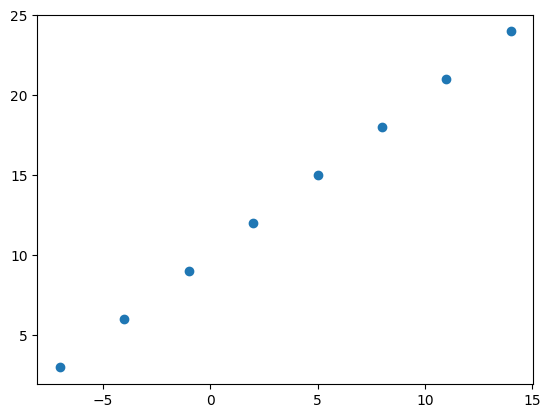

In [2]:
# create features
x = np.array([-7.,-4.,-1.,2.,5.,8.,11.,14.])
# create labels
y = np.array([3.,6.,9.,12.,15.,18.,21.,24.])
# visualize it
plt.scatter(x,y)

In [3]:
# realtion between dependant and independant
y == x + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

Input and Output Shapes

In [4]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [5]:
x[0],y[0]

(np.float64(-7.0), np.float64(3.0))

In [6]:
x[0].ndim

0

In [7]:
x = tf.constant(x)
y = tf.constant(y)
x,y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [8]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape # no dims means its a scalar val

(TensorShape([]), TensorShape([]))

In [9]:
x = tf.expand_dims(x,axis=-1) # since Sequential is expecting a min of 2 Dims
y = tf.expand_dims(y,axis=-1)
x,y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]])>)

In [52]:
## modelling with tensorflow

# set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # '1' tells that there is 1 output neuron (basic linear calculation)
    # this makes it a simple linear regression model
])

# 2. Complie the code
model.compile(loss=tf.keras.losses.mae, # mae- mean absolute error
               optimizer = tf.keras.optimizers.SGD(), # SGD- stochastic gradient of descent
               # an optimizer tells the neural network how to improve
               metrics = ["mae"])

# Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5, verbose=0) # epochs - no. of runs to find the pattern

In [11]:
# check out x and y
x,y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]])>)

In [12]:
# make a prediction
model.predict(tf.constant([[17.0]])) # x = 17.0 should give y = 27

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


array([[-15.603942]], dtype=float32)

Improving our Model

In [53]:
# create another model

# 1. create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. train the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# 3. compile the model
model.fit(tf.expand_dims(x, axis=-1),y,epochs = 100, verbose=0) # earlier epoch was 5

In [14]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[29.735846]], dtype=float32)

In [54]:
# changing the learning rate per epoch
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
              metrics = ["mae"])
model.fit(tf.expand_dims(x, axis=-1),y,epochs = 100, verbose=0)

In [16]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[27.90002]], dtype=float32)

In [55]:
# add an extra hidden layer with the default learning rate to see the difference
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation = "relu"),
    # relu (Rectified Linear Unit) allows the model to learn curves, bends, and complex shapes.
    # now there are 100 neurons trying to find the pattern
    tf.keras.layers.Dense(1)
    # Dense = 1 asks to summarize everything to 1 prediction/ output.
])
model.compile(loss="mae",
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])
model.fit(tf.expand_dims(x, axis=-1),y,epochs=100, verbose=0)

In [18]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[32.814083]], dtype=float32)

In [19]:
# increasing larning rate gave us the best model yet

# Evaluating a Model

build a model --> fit it --> evaluate it --> tweak

In [20]:
# make a bigger dataset
x = tf.range(-100,100,4)
y = x + 10
x,y

(<tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
          76,   80,   84,   88,   92,   96], dtype=int32)>,
 <tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

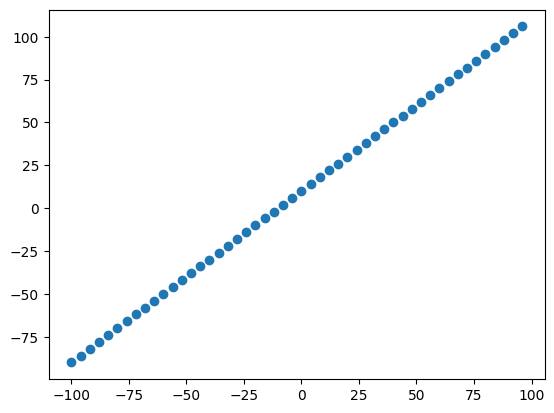

In [21]:
plt.scatter(x, y)

In [22]:
# check length of the samples
len(x), len(y)

(50, 50)

In [23]:
# split data into train and test sets
# skip validation is sample size is small (<100)

x_train = x[:40] # first 40
y_train = y[:40]

x_test = x[40:] # last 10
y_test = y[40:]

len(x_train),len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

Visualising the data


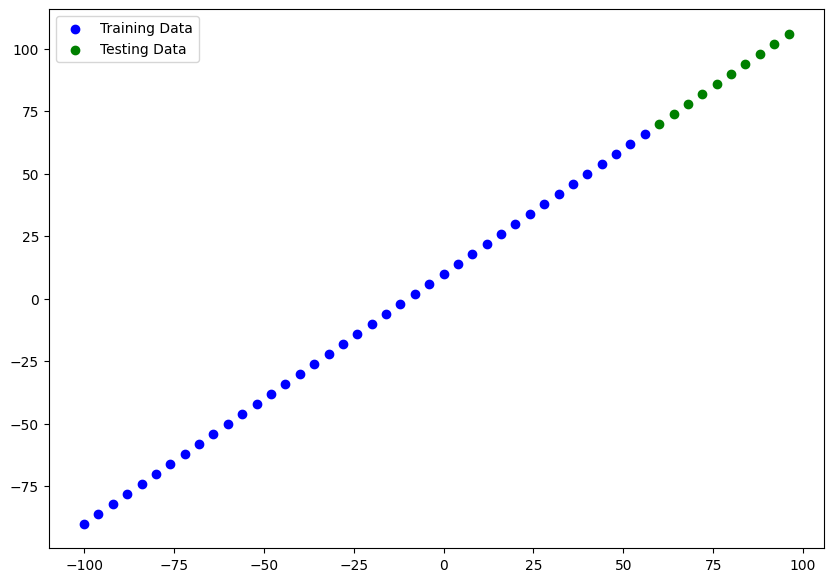

In [24]:
plt.figure(figsize=(10,7)) # 10,7 represents height and width
# plot training data in blue
plt.scatter(x_train, y_train, c = 'b', label="Training Data")
# plot testng data in green
plt.scatter(x_test, y_test, c = 'g', label="Testing Data")
plt.legend();
# ; is to not get matplotlib text output

In [25]:
# building a neural network for our data
'''
# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. Compile the model
model.compile(loss=["mae"],
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"]
              )
# 3. Fit the model on the training data
#model.fit(x_train, y_train, epochs = 100)
'''

'\n# 1. Create a model\nmodel = tf.keras.Sequential([\n    tf.keras.layers.Dense(1)\n])\n# 2. Compile the model\nmodel.compile(loss=["mae"],\n              optimizer = tf.keras.optimizers.SGD(),\n              metrics = ["mae"]\n              )\n# 3. Fit the model on the training data\n#model.fit(x_train, y_train, epochs = 100)\n'

In [26]:
# building a neural net for our data

tf.random.set_seed(42) # for reproduceability

# lets make a model which builds automatically by defining the input_shape arguement in the first layer
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # 1 input for 1 output
])

model.compile(loss = ["mae"],
             optimizer = tf.keras.optimizers.Adam(learning_rate=0.1),
             metrics = ["mae"] # to evaluate the regression model
             )

In [27]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
x_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [29]:
# fit data to our model.

model.fit(x_train,y_train, epochs = 100, verbose = 0)
# verbose = 0 --> dosent tell when each epoch is done
# verbose = 1 --> gives a progressbar

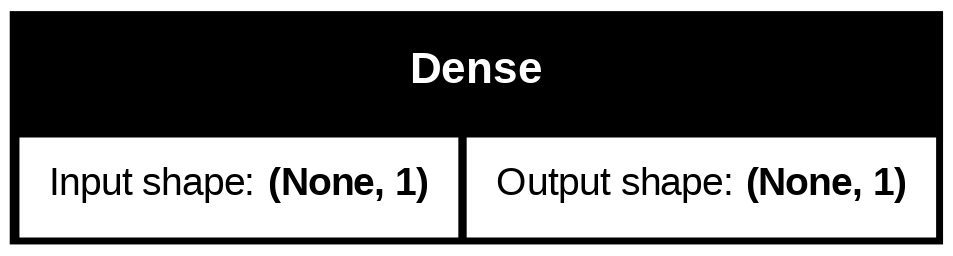

In [30]:
# another way to visualize our model

from tensorflow.keras.utils import plot_model
plot_model(model = model, show_shapes=True)

Visualizing our Model's Prediction

In [31]:
y_pred = model.predict(x_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


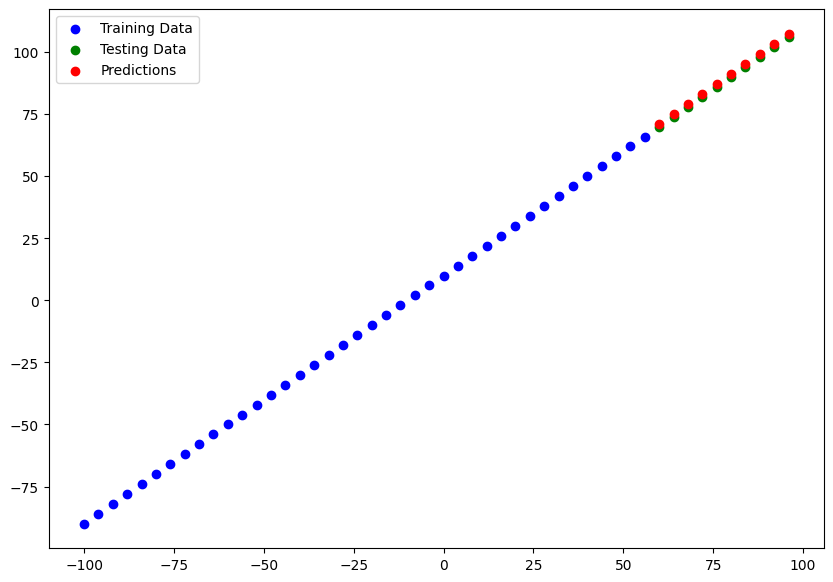

In [32]:
# create a plot function
def plot_predictions(train_data = x_train,
                     train_labels = y_train,
                     test_data = x_test,
                     test_labels = y_test,
                     predictions = y_pred):
  plt.figure(figsize=(10,7))
  # plot trainng data in blue
  plt.scatter(train_data, train_labels, c = 'b', label = "Training Data")
  # plot test data in green
  plt.scatter(test_data, test_labels, c = 'g', label = "Testing Data")
  # plot predictions in red
  plt.scatter(test_data, predictions, c = 'r', label = "Predictions")
  # show legend
  plt.legend();

'''
Plots training data, test data and compares predictions to ground truth
'''

plot_predictions()


In [33]:
x_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

Evaluate the model with regression eval metrics

In [34]:
'''
2 main metrics to evaluate regression models

mae - on average how wrong are the predictions
great starter metric
tf.keras.losses.MAE() (or) tf.metrics.mean_absolute_error()

mse - mean sq. errors, 'square the avg errors''
use when larger errors are more significant than smaller errors
i.e. mse amplifies the larger errors
tf.keras.losses.MSE() (or) tf.metrics.mean_squared_error()

if mae > mse => high accuracy

huber - combination of mse and mae
less sesitive to outliers than mse
tf.keras.losses.Huber()
''';

In [35]:
# Evaluate the model on the test
model.evaluate(x_test, y_test) # metrics = ["MAE"] was set by us earlier

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 1.1280 - mae: 1.1280


[1.1280364990234375, 1.1280364990234375]

In [36]:
tf.squeeze(y_pred) # make y_test, y_pred into same shape to compare
y_test, y_pred

(<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>,
 array([[ 70.866905],
        [ 74.924934],
        [ 78.98296 ],
        [ 83.04099 ],
        [ 87.09902 ],
        [ 91.15705 ],
        [ 95.21508 ],
        [ 99.27311 ],
        [103.33114 ],
        [107.38917 ]], dtype=float32))

In [37]:
# calculate the mean absolute error
mae = tf.keras.losses.MAE(y_test, tf.squeeze(y_pred))

mae

<tf.Tensor: shape=(), dtype=float32, numpy=1.1280364990234375>

In [38]:
# calculate the mean sq error
tf.keras.losses.mse(y_test, tf.squeeze(y_pred))

<tf.Tensor: shape=(), dtype=float32, numpy=1.300247311592102>

In [39]:
x_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [40]:
'''
# make functions to use mae and mse
def mae(y_true = y_test, y_pred = y_pred):
  return tf.metrics.mean.mae(y_test, y_pred)

def mse(y_true = y_test, y_pred = y_pred):
  return tf.metrics.mean.mae(y_test, y_pred)
  '''

'\n# make functions to use mae and mse\ndef mae(y_true = y_test, y_pred = y_pred):\n  return tf.metrics.mean.mae(y_test, y_pred)\n\ndef mse(y_true = y_test, y_pred = y_pred):\n  return tf.metrics.mean.mae(y_test, y_pred)\n  '

In [41]:
x_train,y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

Improving our Model



In [42]:
'''
Usual Methods
1. Get more data
2. Make the model larger -(more layers, hidden units in each layer)
3. Train for longer


3 experiments-

1. model_1 - same as og model
2. model_2 - 2 layers, 100 epochs
3. model_3 - 2 layers, 500 epochs
'''

'\nUsual Methods\n1. Get more data\n2. Make the model larger -(more layers, hidden units in each layer)\n3. Train for longer\n\n\n3 experiments-\n\n1. model_1 - same as og model\n2. model_2 - 2 layers, 100 epochs\n3. model_3 - 2 layers, 500 epochs\n'

In [43]:
x_train.ndim == y_train.ndim, x_train.shape == y_train.shape

(True, True)

In [44]:
# model_1

tf.random.set_seed(42)
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
    ])

model_1.compile(loss = ["mae"],
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["mae"])

# x_train needs to be expanded to 2 dims or tensorflow wont accept it as an input
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs = 100, verbose = 0)

In [45]:
y_preds_1 = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


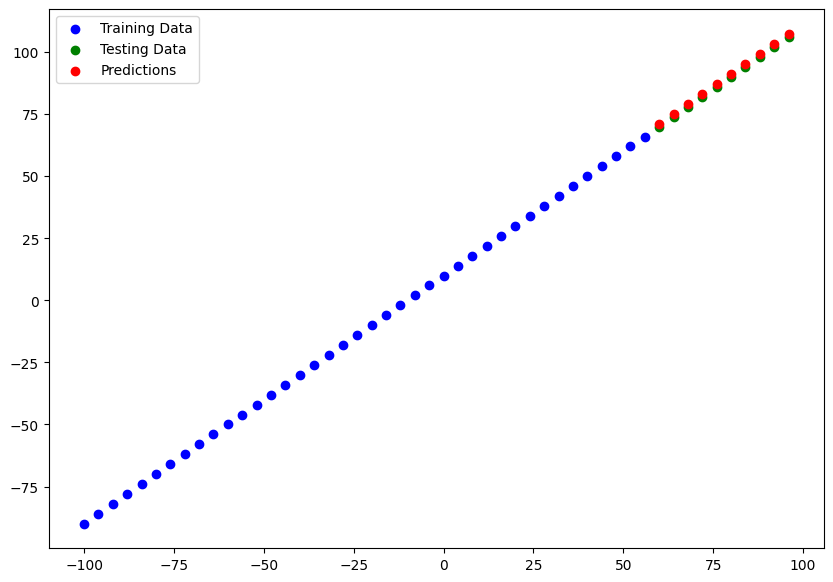

In [46]:
plot_predictions(predictions = y_preds_1)